In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import stim
import numpy as np
import pymatching

from qecsim.surface_code_rotated.circuit import Rotated_Surface_Code

In [115]:
noise = 0

c_0_z = Rotated_Surface_Code(distance = 3, rounds = 3, log_obs = "Z", state_init = "0", noise_after_clifford_depol = noise, noise_after_reset = noise, noise_depol_data_init = noise, noise_measure_flip = noise)
c_1_z = Rotated_Surface_Code(distance = 3, rounds = 3, log_obs = "Z", state_init = "1", noise_after_clifford_depol = noise, noise_after_reset = noise, noise_depol_data_init = noise, noise_measure_flip = noise)
c_p_x = Rotated_Surface_Code(distance = 3, rounds = 3, log_obs = "X", state_init = "+", noise_after_clifford_depol = noise, noise_after_reset = noise, noise_depol_data_init = noise, noise_measure_flip = noise)
c_m_x = Rotated_Surface_Code(distance = 3, rounds = 3, log_obs = "X", state_init = "-", noise_after_clifford_depol = noise, noise_after_reset = noise, noise_depol_data_init = noise, noise_measure_flip = noise)
c_0_x, rec_pos_log_x = Rotated_Surface_Code(distance = 3, rounds = 3, log_obs = "X", state_init = "0", noise_after_clifford_depol = noise, noise_after_reset = noise, noise_depol_data_init = noise, noise_measure_flip = noise)
c_1_x, rec_pos_log_x = Rotated_Surface_Code(distance = 3, rounds = 3, log_obs = "X", state_init = "1", noise_after_clifford_depol = noise, noise_after_reset = noise, noise_depol_data_init = noise, noise_measure_flip = noise)
c_p_z, rec_pos_log_z = Rotated_Surface_Code(distance = 3, rounds = 3, log_obs = "Z", state_init = "+", noise_after_clifford_depol = noise, noise_after_reset = noise, noise_depol_data_init = noise, noise_measure_flip = noise)
c_m_z, rec_pos_log_z = Rotated_Surface_Code(distance = 3, rounds = 3, log_obs = "Z", state_init = "-", noise_after_clifford_depol = noise, noise_after_reset = noise, noise_depol_data_init = noise, noise_measure_flip = noise)

In [ ]:
def building_ptm(circuit_0_z: stim.Circuit, circuit_1_z: stim.Circuit, 
                 circuit_0_x: stim.Circuit, circuit_1_x: stim.Circuit, 
                 circuit_p_x: stim.Circuit, circuit_m_x: stim.Circuit, 
                 circuit_p_z: stim.Circuit, circuit_m_z: stim.Circuit,
                 rec_pos_log_x : list, rec_pos_log_z : list, samples : int = 50) -> np.ndarray:

    """
    Building PTM by building each possible memory circuit and measurement combination
    -> + logical -> Measuring in x/z/y basis
    -> - logical -> Measuring in x/z/y basis
    -> 0 logical -> Measuring in x/z/y basis
    -> 1 logical -> Measuring in x/z/y basis
    -> +i logical -> Measuring in x/z/y basis

    What we do:
        * Determine the noise clean expectation of the measurement
        * Compute the noisy current observable status (xor noiseless initlial state by obs state)
        * Run QEC and check whether the noisy observable should be flipped or not
        * Flip the observable i.e. the clean expectation value
        * Build up PTM out of the expectaition values
     """

    #####################################
    # Builing Diagonal Entries of the PTM
    #####################################

    # Correct nosieless Measurements
    clean_meas_0_z = False
    clean_meas_1_z = True
    clean_meas_p_x = False
    clean_meas_m_x = True

    # Build a graphlike DEM and a matcher
    dem_0_z = circuit_0_z.detector_error_model(decompose_errors=True)
    m_0_z = pymatching.Matching.from_detector_error_model(dem_0_z)
    dem_1_z = circuit_1_z.detector_error_model(decompose_errors=True)
    m_1_z = pymatching.Matching.from_detector_error_model(dem_1_z)
    dem_p_x = circuit_p_x.detector_error_model(decompose_errors=True)
    m_p_x = pymatching.Matching.from_detector_error_model(dem_p_x)
    dem_m_x = circuit_m_x.detector_error_model(decompose_errors=True)
    m_m_x = pymatching.Matching.from_detector_error_model(dem_m_x)

    # Take m shots of detection events
    sampler_0_z = circuit_0_z.compile_detector_sampler()
    dets_0_z, obs_0_z = sampler_0_z.sample(samples, separate_observables=True)
    
    sampler_1_z = circuit_1_z.compile_detector_sampler()
    dets_1_z, obs_1_z = sampler_1_z.sample(samples, separate_observables=True)

    sampler_p_x = circuit_p_x.compile_detector_sampler()
    dets_p_x, obs_p_x = sampler_p_x.sample(samples, separate_observables=True)
    
    sampler_m_x = circuit_m_x.compile_detector_sampler()
    dets_m_x, obs_m_x = sampler_m_x.sample(samples, separate_observables=True)

    # Determine current noisy Operator states (i.e. xor obs from det sample with noiseless Measurement outcome)
    """
    THIS IS TOO MUCH WORK AND CAN BE SIMPLIFIED
    -> Just return freom each circuit the log rec tragets not only for the non determinstic emasurements
    -> Do analogue method than for the off diagonals
    -> This works but is more complicated and results in two methods beeing used in one function which can be mitigated
    """

    noisy_meas_0_z = []
    noisy_meas_1_z = []
    noisy_meas_p_x = []
    noisy_meas_m_x = []

    for curr_shot in range(samples):
        noisy_meas_0_z.append(obs_0_z[:,0] ^ clean_meas_0_z)
        noisy_meas_1_z.append(obs_1_z[:,0] ^ clean_meas_1_z)
        noisy_meas_p_x.append(obs_p_x[:,0] ^ clean_meas_p_x)
        noisy_meas_m_x.append(obs_m_x[:,0] ^ clean_meas_m_x)

    # Decode all sample round in one Batch decode
    pred_0_z = m_0_z.decode_batch(dets_0_z)
    pred_1_z = m_1_z.decode_batch(dets_1_z)
    pred_p_x = m_p_x.decode_batch(dets_p_x)
    pred_m_x = m_m_x.decode_batch(dets_m_x)

    # XOR flip with noiseless Measurement
    # -> Taking first entry for first logical observable
    final_meas_0_z = []
    final_meas_1_z = []
    final_meas_p_x = []
    final_meas_m_x = []

    for curr_shot in range(samples):
        final_meas_0_z = 1 - 2 * (pred_0_z[curr_shot,0].astype(np.int8) ^ np.int8(noisy_meas_0_z[curr_shot]))
        final_meas_1_z = 1 - 2 * (pred_1_z[curr_shot,0].astype(np.int8) ^ np.int8(noisy_meas_1_z[curr_shot]))
        final_meas_p_x = 1 - 2 * (pred_p_x[curr_shot,0].astype(np.int8) ^ np.int8(noisy_meas_p_x[curr_shot]))
        final_meas_m_x = 1 - 2 * (pred_m_x[curr_shot,0].astype(np.int8) ^ np.int8(noisy_meas_m_x[curr_shot]))

    # Take the Average of each of them
    mu_z_pz = np.average(final_meas_0_z)
    mu_z_mz = np.average(final_meas_1_z)
    mu_x_px = np.average(final_meas_p_x)
    mu_x_mx = np.average(final_meas_m_x)

    # Calc PTM entries
    r_zz = 1/2 * (mu_z_pz - mu_z_mz)
    r_xx = 1/2 * (mu_x_px - mu_x_mx)

    ######################################
    # Building Off-Diagonals of the Matrix
    ######################################

    """
    For the Off-Diagonals we can't directly use the DEM as we need the raw measurements to infer what logical state we have

    -> We use compile sampler to infer the logical state
    -> Convert into a dem to run the matching
    """

    # Build the normal measurement smaples and sample n shots
    smpl_0_x = circuit_0_x.compile_sampler()
    rstls_smpls_0_x = smpl_0_x.sample(shots = samples)
    smpl_1_x = circuit_1_x.compile_sampler()
    rstls_smpls_1_x = smpl_1_x.sample(shots = samples)
    smpl_p_z = circuit_p_z.compile_sampler()
    rstls_smpls_p_z = smpl_p_z.sample(shots = samples)
    smpl_m_z = circuit_m_z.compile_sampler()
    rstls_smpls_m_z = smpl_m_z.sample(shots = samples)

    # Getting the individual logical states after measurement
    log_state_0_x = []
    log_state_1_x = []
    log_state_p_z = []
    log_state_m_z = []

    for curr_shot in range(samples):

        measurement_res_0_x = -99
        measurement_res_1_x = -99
        measurement_res_p_z = -99
        measurement_res_m_z = -99

        # Do the first loop for all x basis measurements
        for current_tar_rec in rec_pos_log_x:
            
            # If this is the first, set the resutl to this measurement outcome
            if measurement_res_0_x == -99:
                measurement_res_0_x = rstls_smpls_0_x[curr_shot, current_tar_rec]

            # else xor measurement to the already present ones
            else:
                measurement_res_0_x ^= rstls_smpls_0_x[curr_shot, current_tar_rec]

            # If this is the first, set the resutl to this measurement outcome
            if measurement_res_1_x == -99:
                measurement_res_1_x = rstls_smpls_1_x[curr_shot, current_tar_rec]

            # else xor measurement to the already present ones
            else:
                measurement_res_1_x ^= rstls_smpls_1_x[curr_shot, current_tar_rec]

        # Do the same for z
        for current_tar_rec in rec_pos_log_z:
            
            # If this is the first, set the resutl to this measurement outcome
            if measurement_res_p_z == -99:
                measurement_res_p_z = rstls_smpls_p_z[curr_shot, current_tar_rec]

            # else xor measurement to the already present ones
            else:
                measurement_res_p_z ^= rstls_smpls_p_z[curr_shot, current_tar_rec]

            # If this is the first, set the resutl to this measurement outcome
            if measurement_res_m_z == -99:
                measurement_res_m_z = rstls_smpls_m_z[curr_shot, current_tar_rec]

            # else xor measurement to the already present ones
            else:
                measurement_res_m_z ^= rstls_smpls_m_z[curr_shot, current_tar_rec]

        # Appending the current measurements to the list
        log_state_0_x.append(measurement_res_0_x)
        log_state_1_x.append(measurement_res_1_x)
        log_state_p_z.append(measurement_res_p_z)
        log_state_m_z.append(measurement_res_m_z)

    # Build a graphlike DEM and a matcher
    dem_0_x = circuit_0_x.detector_error_model(decompose_errors=True)
    m_0_x = pymatching.Matching.from_detector_error_model(dem_0_x)
    dem_1_x = circuit_1_x.detector_error_model(decompose_errors=True)
    m_1_x = pymatching.Matching.from_detector_error_model(dem_1_x)
    dem_p_z = circuit_p_z.detector_error_model(decompose_errors=True)
    m_p_z = pymatching.Matching.from_detector_error_model(dem_p_z)
    dem_m_z = circuit_m_z.detector_error_model(decompose_errors=True)
    m_m_z = pymatching.Matching.from_detector_error_model(dem_m_z)

    # Converting the measurement sample into DEM sample and continue as usual with decoding
    cvrtr_0_x = circuit_0_x.compile_m2d_converter()
    dets_ops_0_x = cvrtr_0_x.convert(measurements = rstls_smpls_0_x, append_observables=True)
    num_dets = dem_0_x.num_detectors
    num_obs  = dem_0_x.num_observables
    dets_0_x = dets_ops_0_x[:, :num_dets]
    obs_0_x  = dets_ops_0_x[:, num_dets:num_dets+num_obs]


    cvrtr_1_x = circuit_1_x.compile_m2d_converter()
    dets_ops_1_x = cvrtr_1_x.convert(measurements = rstls_smpls_1_x, append_observables=True)
    num_dets = dem_1_x.num_detectors
    num_obs  = dem_1_x.num_observables
    dets_1_x = dets_ops_1_x[:, :num_dets]
    obs_1_x  = dets_ops_1_x[:, num_dets:num_dets+num_obs]


    cvrtr_p_z = circuit_p_z.compile_m2d_converter()
    dets_ops_p_z = cvrtr_p_z.convert(measurements = rstls_smpls_p_z, append_observables=True)
    num_dets = dem_p_z.num_detectors
    num_obs  = dem_p_z.num_observables
    dets_p_z = dets_ops_p_z[:, :num_dets]
    obs_p_z  = dets_ops_p_z[:, num_dets:num_dets+num_obs]


    cvrtr_m_z = circuit_m_z.compile_m2d_converter()
    dets_ops_m_z = cvrtr_m_z.convert(measurements = rstls_smpls_m_z, append_observables=True)
    num_dets = dem_m_z.num_detectors
    num_obs  = dem_m_z.num_observables
    dets_m_z = dets_ops_m_z[:, :num_dets]
    obs_m_z  = dets_ops_m_z[:, num_dets:num_dets+num_obs]

    # Decode all sample round in one Batch decode
    pred_0_x = m_0_x.decode_batch(dets_0_x)
    pred_1_x = m_1_x.decode_batch(dets_1_x)
    pred_p_z = m_p_z.decode_batch(dets_p_z)
    pred_m_z = m_m_z.decode_batch(dets_m_z)

    # Init final state List after EC
    final_meas_0_x : list = []
    final_meas_1_x : list = []
    final_meas_p_z : list = []
    final_meas_m_z : list = []

    # XOR flip with noiseless Measurement (looping over all samples and compoaring to the current logical outcome in the list)
    # -> Taking first entry for first logical observable
    for current_sample in range(samples):
        curr_meas_0_x = 1 - 2 * (pred_0_x[current_sample,0].astype(np.int8) ^ np.int8(log_state_0_x[current_sample]))
        curr_meas_1_x = 1 - 2 * (pred_1_x[current_sample,0].astype(np.int8) ^ np.int8(log_state_1_x[current_sample]))
        curr_meas_p_z = 1 - 2 * (pred_p_z[current_sample,0].astype(np.int8) ^ np.int8(log_state_p_z[current_sample]))
        curr_meas_m_z = 1 - 2 * (pred_m_z[current_sample,0].astype(np.int8) ^ np.int8(log_state_m_z[current_sample]))

        #Adding final XORed measurement into the list
        final_meas_0_x.append(curr_meas_0_x)
        final_meas_1_x.append(curr_meas_1_x)
        final_meas_p_z.append(curr_meas_p_z)
        final_meas_m_z.append(curr_meas_m_z)

    # Take the Average of each of them
    mu_x_pz = np.average(final_meas_0_x)
    mu_x_mz = np.average(final_meas_1_x)
    mu_z_px = np.average(final_meas_p_z)
    mu_z_mx = np.average(final_meas_m_z)

    # Calc PTM entries
    r_zx = 1/2 * (mu_z_px - mu_z_mx)
    r_xz = 1/2 * (mu_x_pz - mu_x_mz)

    # Create PTM Matrix
    ptm = [
        [r_xx, 0.0, r_xz], 
        [0.0, 0.0 , 0.0], 
        [r_zx, 0.0 , r_zz]]

    return(np.array(ptm))

In [213]:
building_ptm(circuit_0_x = c_0_x, circuit_1_x = c_1_x, circuit_0_z = c_0_z, circuit_1_z = c_1_z,
            circuit_p_x = c_p_x, circuit_m_x = c_m_x, circuit_p_z = c_p_z, circuit_m_z = c_m_z, rec_pos_log_x = rec_pos_log_x, 
            rec_pos_log_z = rec_pos_log_z, samples = 10_000)

array([[1.0e+00, 0.0e+00, 5.7e-03],
       [0.0e+00, 0.0e+00, 0.0e+00],
       [2.0e-04, 0.0e+00, 1.0e+00]])

In [29]:
from qecsim.surface_code_rotated.circuit import Rotated_Surface_Code

Rotated_Surface_Code(distance = 5, rounds = 5, log_obs = "X", state_init = "1").detector_error_model()

stim.DetectorErrorModel('''
    logical_observable L0
    detector(2, 4, 0) D0
    detector(2, 8, 0) D1
    detector(4, 2, 0) D2
    detector(4, 6, 0) D3
    detector(6, 4, 0) D4
    detector(6, 8, 0) D5
    detector(8, 2, 0) D6
    detector(8, 6, 0) D7
    detector(0, 2, 0) D8
    detector(0, 6, 0) D9
    detector(10, 4, 0) D10
    detector(10, 8, 0) D11
    shift_detectors(0, 0, 1) 0
    detector(2, 2, 0) D12
    detector(2, 6, 0) D13
    detector(4, 4, 0) D14
    detector(4, 8, 0) D15
    detector(6, 2, 0) D16
    detector(6, 6, 0) D17
    detector(8, 4, 0) D18
    detector(8, 8, 0) D19
    detector(4, 0, 0) D20
    detector(8, 0, 0) D21
    detector(2, 10, 0) D22
    detector(6, 10, 0) D23
    detector(2, 4, 0) D24
    detector(2, 8, 0) D25
    detector(4, 2, 0) D26
    detector(4, 6, 0) D27
    detector(6, 4, 0) D28
    detector(6, 8, 0) D29
    detector(8, 2, 0) D30
    detector(8, 6, 0) D31
    detector(0, 2, 0) D32
    detector(0, 6, 0) D33
    detector(10, 4, 0) D34
    detect

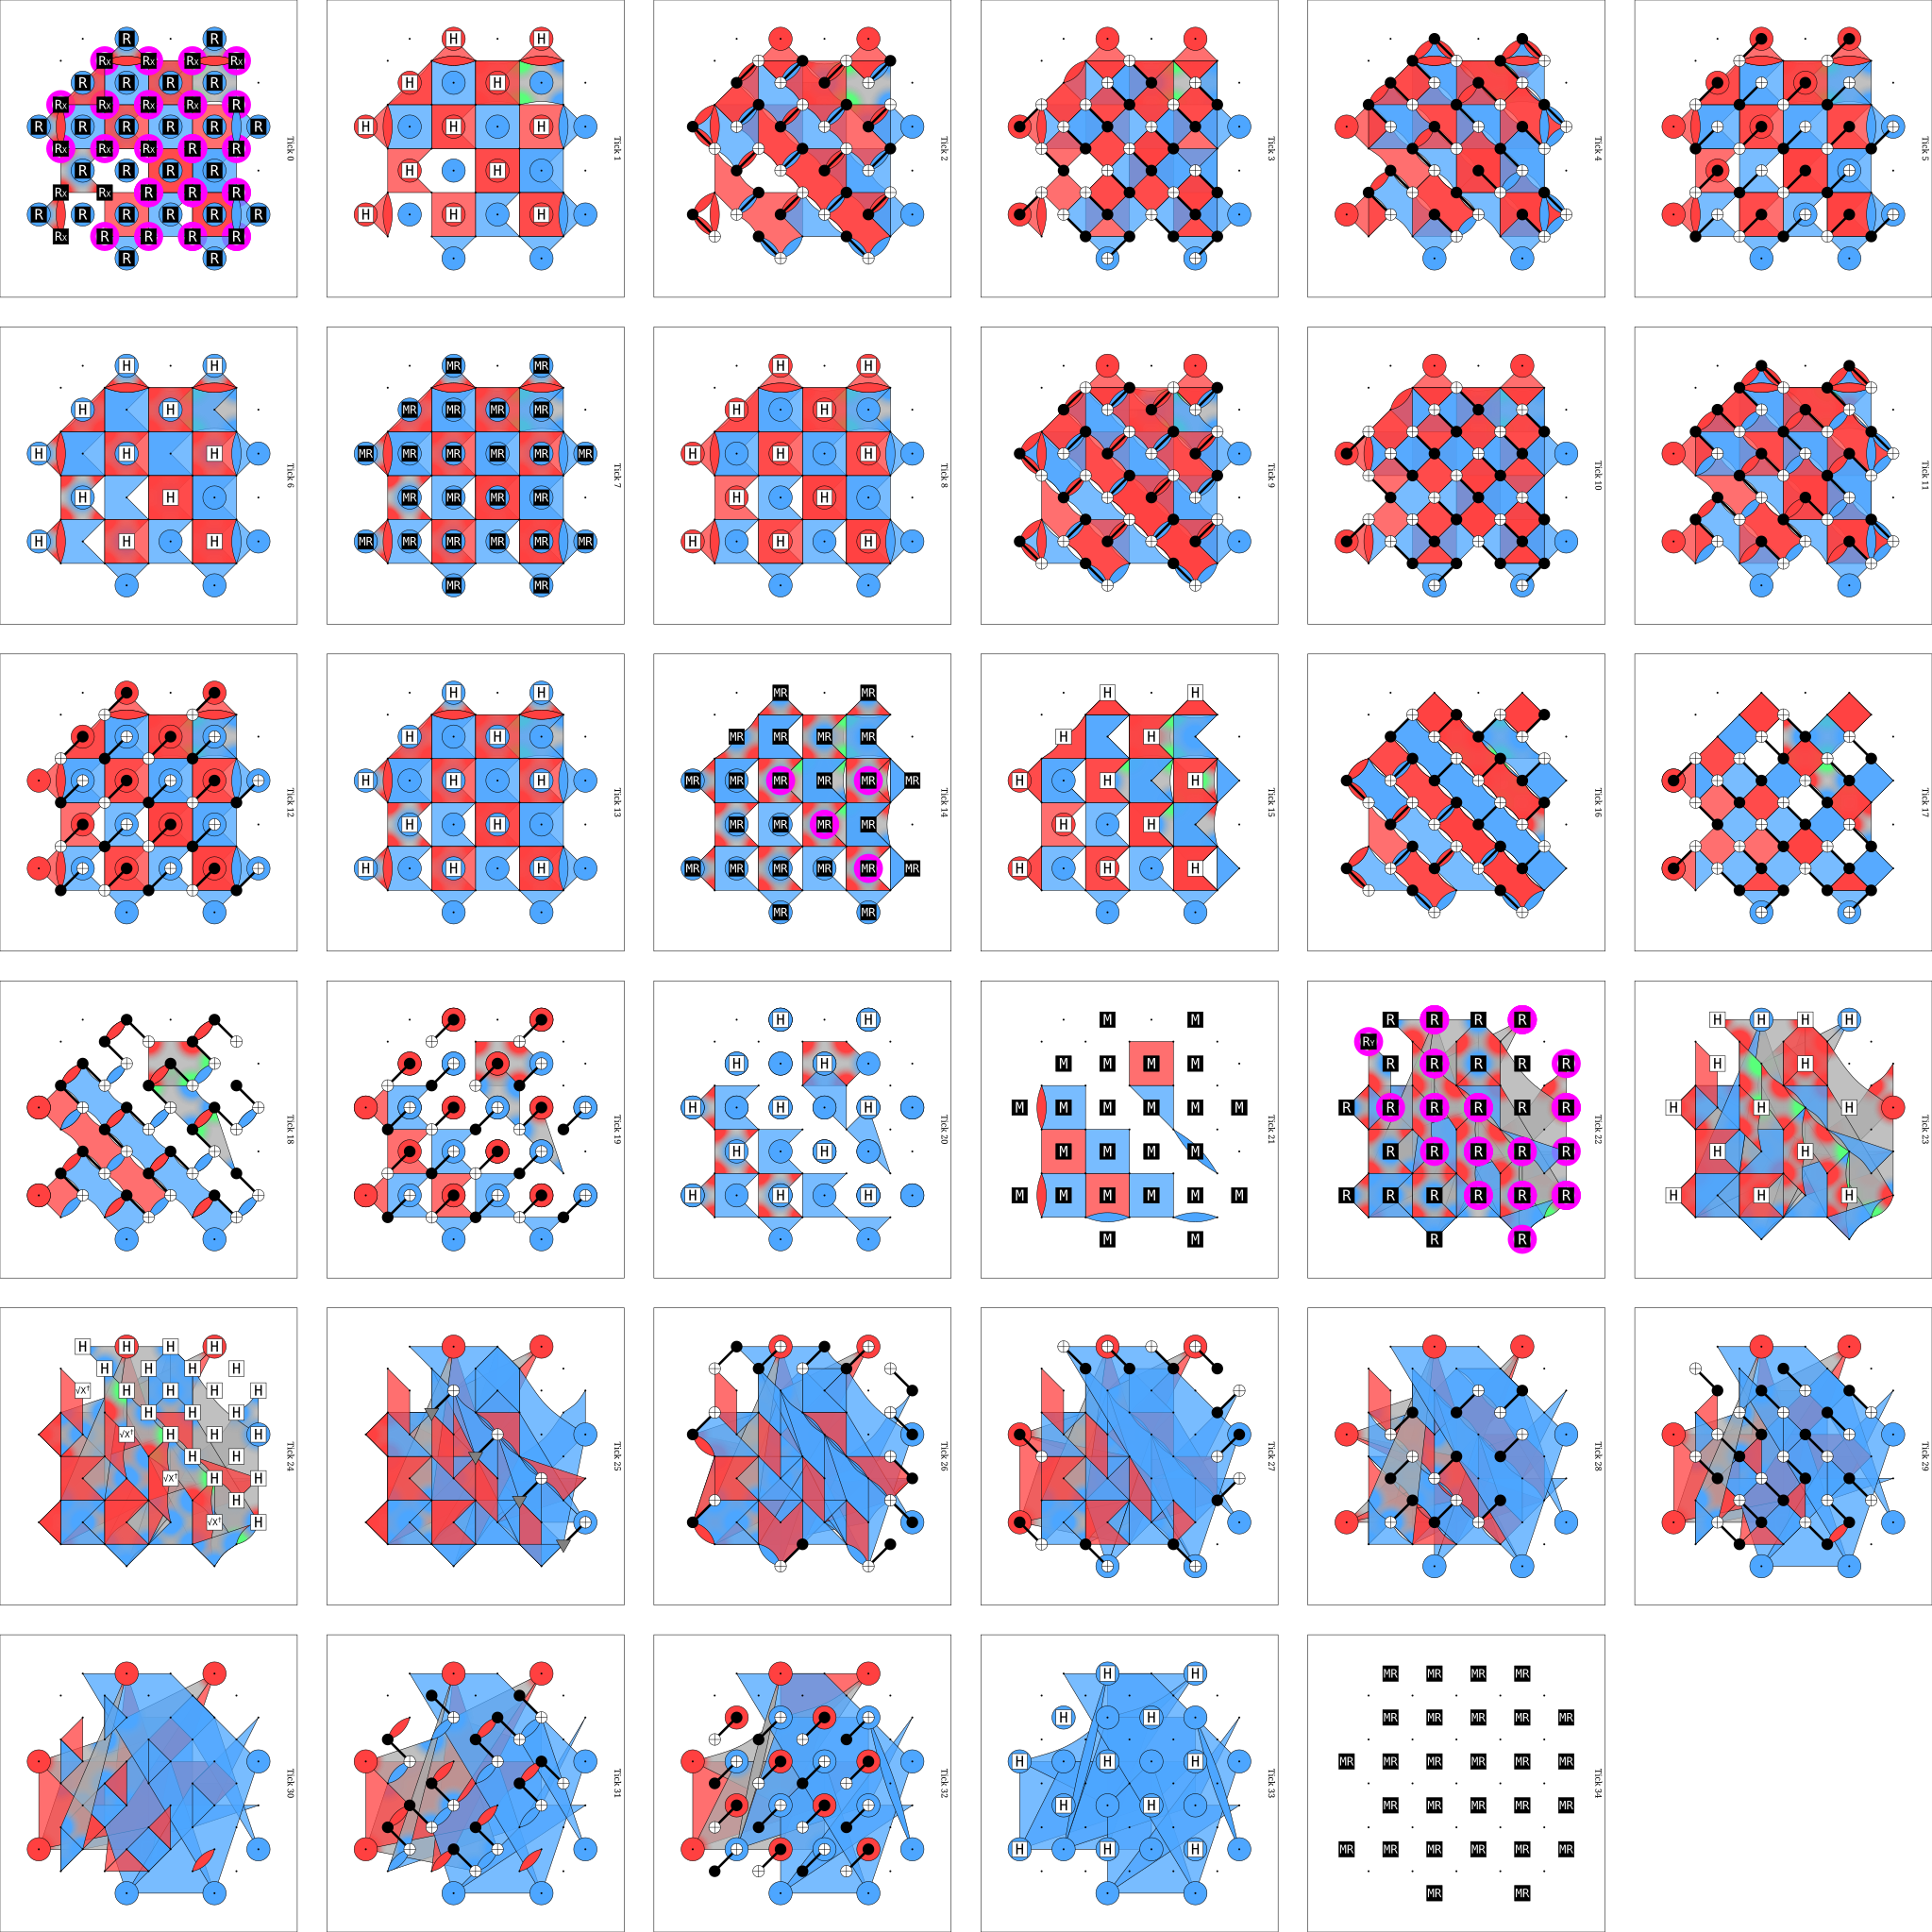

In [177]:
from qecsim.surface_code_rotated.circuit import Rotated_Surface_Code

Rotated_Surface_Code(distance = 5, rounds = 5, log_obs = "Y", state_init = "+i").diagram("detslice-with-ops")

In [8]:
tt = stim.Circuit(
"""
QUBIT_COORDS(0, 2) 0
QUBIT_COORDS(0, 4) 1
QUBIT_COORDS(0.5, 0.5) 2
QUBIT_COORDS(0.5, 1.5) 3
QUBIT_COORDS(0.5, 2.5) 4
QUBIT_COORDS(0.5, 3.5) 5
QUBIT_COORDS(0.5, 4.5) 6
QUBIT_COORDS(1, 0) 7
QUBIT_COORDS(1, 1) 8
QUBIT_COORDS(1, 2) 9
QUBIT_COORDS(1, 3) 10
QUBIT_COORDS(1, 4) 11
QUBIT_COORDS(1.5, 0.5) 12
QUBIT_COORDS(1.5, 1.5) 13
QUBIT_COORDS(1.5, 2.5) 14
QUBIT_COORDS(1.5, 3.5) 15
QUBIT_COORDS(1.5, 4.5) 16
QUBIT_COORDS(2, 0) 17
QUBIT_COORDS(2, 1) 18
QUBIT_COORDS(2, 2) 19
QUBIT_COORDS(2, 3) 20
QUBIT_COORDS(2, 4) 21
QUBIT_COORDS(2, 5) 22
QUBIT_COORDS(2.5, 0.5) 23
QUBIT_COORDS(2.5, 1.5) 24
QUBIT_COORDS(2.5, 2.5) 25
QUBIT_COORDS(2.5, 3.5) 26
QUBIT_COORDS(2.5, 4.5) 27
QUBIT_COORDS(3, 0) 28
QUBIT_COORDS(3, 1) 29
QUBIT_COORDS(3, 2) 30
QUBIT_COORDS(3, 3) 31
QUBIT_COORDS(3, 4) 32
QUBIT_COORDS(3.5, 0.5) 33
QUBIT_COORDS(3.5, 1.5) 34
QUBIT_COORDS(3.5, 2.5) 35
QUBIT_COORDS(3.5, 3.5) 36
QUBIT_COORDS(3.5, 4.5) 37
QUBIT_COORDS(4, 0) 38
QUBIT_COORDS(4, 1) 39
QUBIT_COORDS(4, 2) 40
QUBIT_COORDS(4, 3) 41
QUBIT_COORDS(4, 4) 42
QUBIT_COORDS(4, 5) 43
QUBIT_COORDS(4.5, 0.5) 44
QUBIT_COORDS(4.5, 1.5) 45
QUBIT_COORDS(4.5, 2.5) 46
QUBIT_COORDS(4.5, 3.5) 47
QUBIT_COORDS(4.5, 4.5) 48
QUBIT_COORDS(5, 1) 49
QUBIT_COORDS(5, 2) 50
QUBIT_COORDS(5, 3) 51
QUBIT_COORDS(5, 4) 52
TICK
R 25 15 14 13 24 34 44 33 23 12 3 4 5 6
RX 45 46 35 47 36 26 48 37 27 16
TICK
R 0 1 42 40 38 31 29 21 19 17 10 8
RX 52 50 43 41 39 32 30 22 20 18 11 9
TICK
CX 37 42 35 40 33 38 26 31 24 29 16 21 14 19 12 17 5 10 3 8 52 48 50 46 41 36 39 34 32 27 30 25 20 15 18 13 11 6 9 4
TICK
CX 41 47 39 45 32 37 30 35 20 26 18 24 11 16 9 14 36 42 34 40 25 31 23 29 15 21 13 19 4 10
TICK
CX 52 47 50 45 43 37 41 35 39 33 32 26 30 24 22 16 20 14 18 12 11 5 9 3 4 0 6 1 48 42 46 40 44 38 36 31 34 29 27 21 25 19 23 17 15 10 13 8
TICK
CX 43 48 41 46 39 44 32 36 30 34 22 27 20 25 18 23 11 15 9 13 3 0 5 1 47 42 45 40 35 31 33 29 26 21 24 19 14 10 12 8
TICK
M 1 0 42 40 38 31 29 21 19 17 10 8
MX 52 50 43 41 39 32 30 22 20 18 11 9
DETECTOR(0, 4, 0) rec[-24]
DETECTOR(0, 2, 0) rec[-23]
DETECTOR(4, 0, 0) rec[-20]
DETECTOR(3, 1, 0) rec[-18]
DETECTOR(2, 2, 0) rec[-16]
DETECTOR(2, 0, 0) rec[-15]
DETECTOR(1, 3, 0) rec[-14]
DETECTOR(1, 1, 0) rec[-13]
DETECTOR(5, 4, 0) rec[-12]
DETECTOR(5, 2, 0) rec[-11]
DETECTOR(4, 5, 0) rec[-10]
DETECTOR(4, 3, 0) rec[-9]
DETECTOR(3, 4, 0) rec[-7]
DETECTOR(2, 5, 0) rec[-5]
TICK
R 0 1 42 40 38 31 29 21 19 17 10 8
RX 52 50 43 41 39 32 30 22 20 18 11 9
TICK
CX 37 42 35 40 33 38 26 31 24 29 16 21 14 19 12 17 5 10 3 8 52 48 50 46 41 36 39 34 32 27 30 25 20 15 18 13 11 6 9 4
TICK
CX 41 47 39 45 32 37 30 35 20 26 18 24 11 16 9 14 36 42 34 40 25 31 23 29 15 21 13 19 4 10
TICK
CX 52 47 50 45 43 37 41 35 39 33 32 26 30 24 22 16 20 14 18 12 11 5 9 3 4 0 6 1 48 42 46 40 44 38 36 31 34 29 27 21 25 19 23 17 15 10 13 8
TICK
CX 43 48 41 46 39 44 32 36 30 34 22 27 20 25 18 23 11 15 9 13 3 0 5 1 47 42 45 40 35 31 33 29 26 21 24 19 14 10 12 8
TICK
M 1 0 42 40 38 31 29 21 19 17 10 8
MX 52 50 43 41 39 32 30 22 20 18 11 9
DETECTOR(0, 4, 1) rec[-24] rec[-48]
DETECTOR(0, 2, 1) rec[-23] rec[-47]
DETECTOR(4, 4, 1) rec[-22] rec[-46]
DETECTOR(4, 2, 1) rec[-21] rec[-45]
DETECTOR(4, 0, 1) rec[-20] rec[-44]
DETECTOR(3, 3, 1) rec[-19] rec[-43]
DETECTOR(3, 1, 1) rec[-18] rec[-42]
DETECTOR(2, 4, 1) rec[-17] rec[-41]
DETECTOR(2, 2, 1) rec[-16] rec[-40]
DETECTOR(2, 0, 1) rec[-15] rec[-39]
DETECTOR(1, 3, 1) rec[-14] rec[-38]
DETECTOR(1, 1, 1) rec[-13] rec[-37]
DETECTOR(5, 4, 1) rec[-12] rec[-36]
DETECTOR(5, 2, 1) rec[-11] rec[-35]
DETECTOR(4, 5, 1) rec[-10] rec[-34]
DETECTOR(4, 3, 1) rec[-9] rec[-33]
DETECTOR(4, 1, 1) rec[-8] rec[-32]
DETECTOR(3, 4, 1) rec[-7] rec[-31]
DETECTOR(3, 2, 1) rec[-6] rec[-30]
DETECTOR(2, 5, 1) rec[-5] rec[-29]
DETECTOR(2, 3, 1) rec[-4] rec[-28]
DETECTOR(2, 1, 1) rec[-3] rec[-27]
DETECTOR(1, 4, 1) rec[-2] rec[-26]
DETECTOR(1, 2, 1) rec[-1] rec[-25]
TICK
TICK
R 42 40 38 31 29 28 21 19 17 10 8 7 1 0
RX 52 51 50 49 43 41 39 32 30 22 20 18 11 9
RY 2
TICK
H 52 51 50 49 41 40 39 38 30 29 28 18 17 7 47 46 45 44 35 34 33 24 23 12
SQRT_X_DAG 42 31 19 8
TICK
XCY 48 52 36 41 25 30 13 18
TICK
CX 26 21 14 10 5 1 3 0 43 48 32 36 22 27 20 25 11 15 9 13 51 47 49 45 40 35 38 33 29 24 17 12 46 50 34 39 23 28
TICK
CX 27 21 15 10 6 1 4 0 43 37 32 26 22 16 20 14 11 5 9 3 40 46 38 44 29 34 17 23 47 52 45 50 35 41 33 39 24 30 12 18
XCY 42 48 31 36 19 25 8 13
TICK
CX 46 51 44 49 36 42 34 40 25 31 23 29 15 21 13 19 4 10 2 8 41 47 39 45 32 37 30 35 28 33 20 26 18 24 11 16 9 14 7 12
TICK
CX 47 51 45 49 37 42 35 40 26 31 24 29 16 21 14 19 5 10 3 8 41 36 39 34 32 27 30 25 28 23 20 15 18 13 11 6 9 4 7 2
TICK
M 52 51 50 49 42 40 31 29 21 19 10 8 1 0
MX 43 41 39 38 32 30 28 22 20 18 17 11 9 7
DETECTOR(5, 4, 2) rec[-28] rec[-40]
DETECTOR(4, 3, 2) rec[-27] rec[-37]
DETECTOR(5, 2, 2) rec[-26] rec[-39]
DETECTOR(4, 1, 2) rec[-25] rec[-36]
DETECTOR(3, 2, 2) rec[-23] rec[-34]
DETECTOR(2, 1, 2) rec[-21] rec[-31]
DETECTOR(2, 4, 2) rec[-20] rec[-45]
DETECTOR(1, 3, 2) rec[-18] rec[-42]
DETECTOR(0, 4, 2) rec[-16] rec[-52]
DETECTOR(0, 2, 2) rec[-15] rec[-51]
DETECTOR(4, 5, 2) rec[-14] rec[-38]
DETECTOR(4, 4, 2) rec[-13] rec[-24] rec[-50]
DETECTOR(4, 2, 2) rec[-12] rec[-49]
DETECTOR(4, 0, 2) rec[-11] rec[-48]
DETECTOR(3, 4, 2) rec[-10] rec[-35]
DETECTOR(3, 3, 2) rec[-9] rec[-22] rec[-47]
DETECTOR(3, 1, 2) rec[-8] rec[-46]
DETECTOR(2, 5, 2) rec[-7] rec[-33]
DETECTOR(2, 3, 2) rec[-6] rec[-32]
DETECTOR(2, 2, 2) rec[-5] rec[-19] rec[-44]
DETECTOR(2, 0, 2) rec[-4] rec[-43]
DETECTOR(1, 4, 2) rec[-3] rec[-30]
DETECTOR(1, 2, 2) rec[-2] rec[-29]
DETECTOR(1, 1, 2) rec[-1] rec[-17] rec[-41]
TICK
TICK
MPP X33*X23 X12*X2 X27*X37*X36*X26 X25*X35*X34*X24 X4*X14*X13*X3 X6*X16*X15*X5
DETECTOR(3, 0, 3) rec[-6] rec[-14]
DETECTOR(1, 0, 3) rec[-5] rec[-7]
DETECTOR(3, 4, 3) rec[-4] rec[-16]
DETECTOR(3, 2, 3) rec[-3] rec[-15]
DETECTOR(1, 2, 3) rec[-2] rec[-8]
DETECTOR(1, 4, 3) rec[-1] rec[-9]
TICK
MPP X48*X37 X27*X16 X36*X47*X46*X35 X34*X45*X44*X33 X13*X24*X23*X12 X15*X26*X25*X14
DETECTOR(4, 5, 4) rec[-6] rec[-26]
DETECTOR(2, 5, 4) rec[-5] rec[-19]
DETECTOR(4, 3, 4) rec[-4] rec[-25]
DETECTOR(4, 0, 4) rec[-3] rec[-23] rec[-24]
DETECTOR(2, 0, 4) rec[-2] rec[-16] rec[-17]
DETECTOR(2, 3, 4) rec[-1] rec[-18]
TICK
MPP Z6*Z5 Z4*Z3 Z35*Z46*Z45*Z34 Z37*Z48*Z47*Z36 Z16*Z27*Z26*Z15 Z14*Z25*Z24*Z13
DETECTOR(0, 4, 5) rec[-6] rec[-34]
DETECTOR(0, 2, 5) rec[-5] rec[-33]
DETECTOR(4, 2, 5) rec[-4] rec[-41] rec[-44]
DETECTOR(4, 4, 5) rec[-3] rec[-42] rec[-46]
DETECTOR(2, 4, 5) rec[-2] rec[-38]
DETECTOR(2, 2, 5) rec[-1] rec[-37]
TICK
MPP Z47*Z46 Z45*Z44 Z24*Z34*Z33*Z23 Z26*Z36*Z35*Z25 Z5*Z15*Z14*Z4 Z3*Z13*Z12*Z2
DETECTOR(5, 3, 6) rec[-6] rec[-51]
DETECTOR(5, 1, 6) rec[-5] rec[-49]
DETECTOR(3, 1, 6) rec[-4] rec[-45]
DETECTOR(3, 3, 6) rec[-3] rec[-46]
DETECTOR(1, 3, 6) rec[-2] rec[-42]
DETECTOR(1, 1, 6) rec[-1] rec[-41]
TICK
MPP X6*X5*X4*X3*Y2*Z23*Z12*Z44*Z33
OBSERVABLE_INCLUDE(0) rec[-1] rec[-54] rec[-55] rec[-56] rec[-57] rec[-58] rec[-59] rec[-60] rec[-61] rec[-62] rec[-63] rec[-64] rec[-65]

"""

)

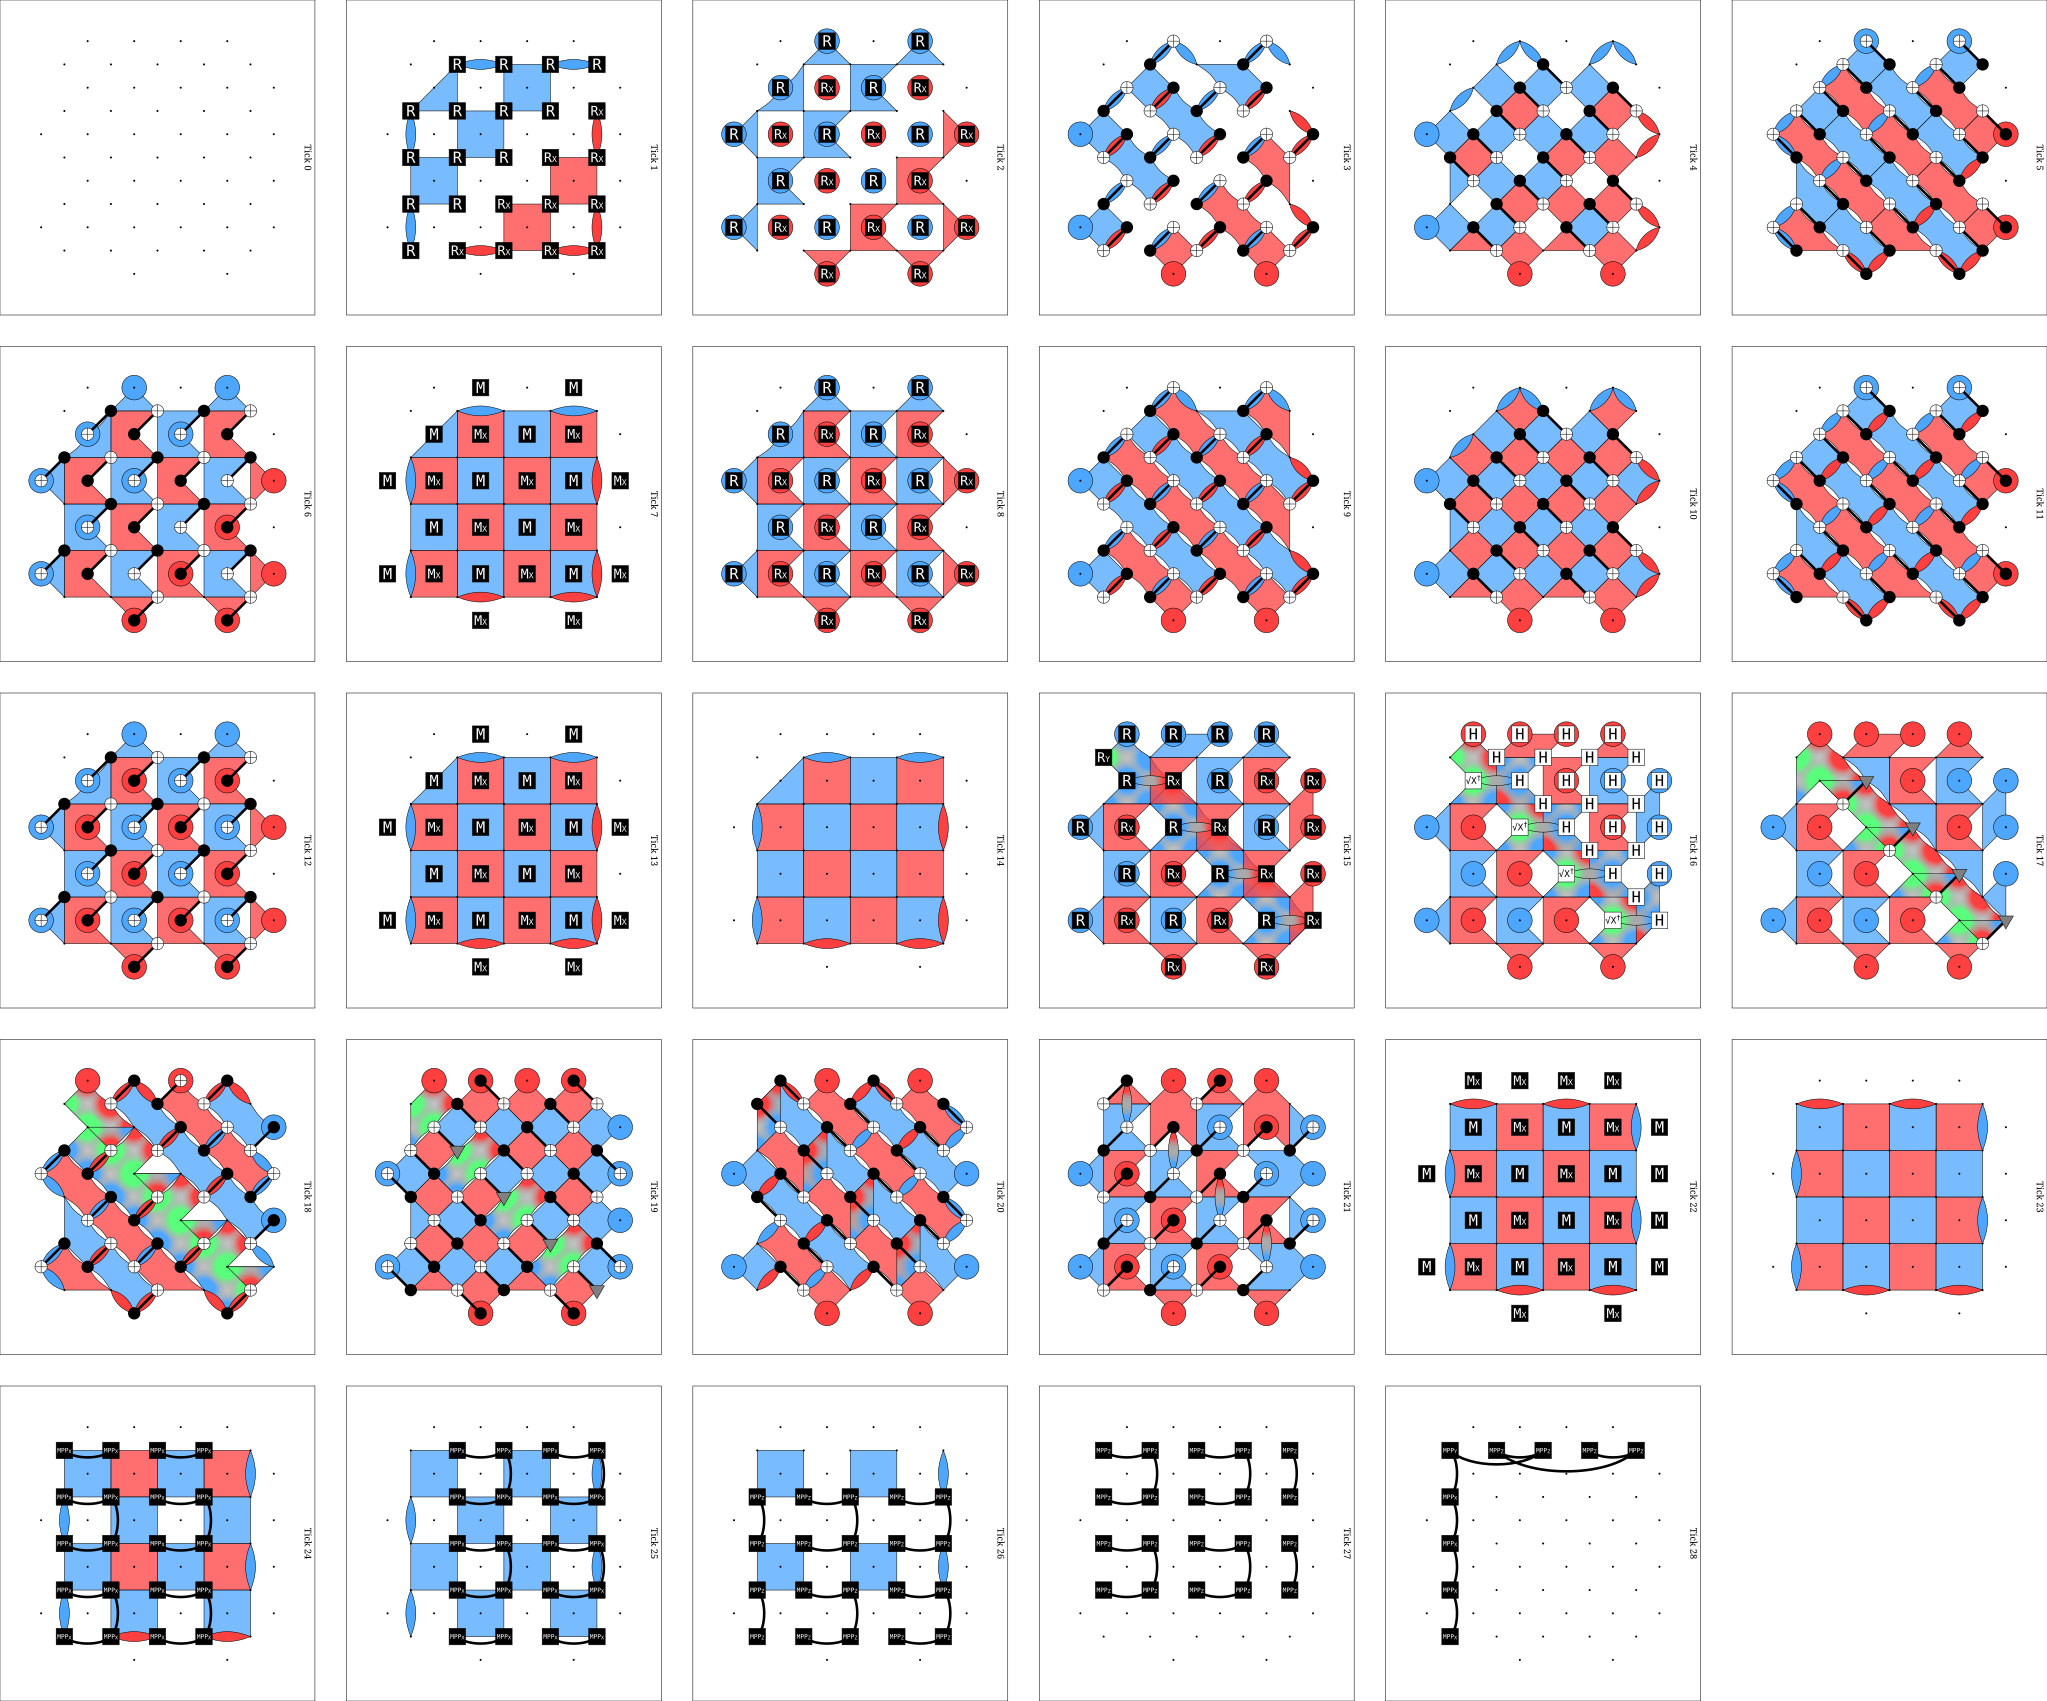

In [9]:
tt.diagram("detslice-with-ops-svg")

In [10]:
int(3/2)

1